<a href="https://www.kaggle.com/code/lalit7881/food-nutrition-pricing-eda?scriptVersionId=320096194" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sridipbasu/global-food-nutrition-dataset-pricing-and-rating/food_menu_nutrition_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sridipbasu/global-food-nutrition-dataset-pricing-and-rating/food_menu_nutrition_dataset.csv")

In [3]:
df.head()

,item_name,item_category,item_subcategory,brand_name,brand_tier,country,city,city_tier,price_usd_normalized,serving_size_g,calories,protein_g,total_fat_g,total_carbs_g,sodium_mg,sugars_g,avg_rating,is_bestseller
0,Veggie Sub,Sandwich,Veg,Five Guys,mid,UK,London,metro,8.66,224.9,438.3,23.4,27.8,46.0,744.4,12.1,4.3,0
1,Waffles with Syrup,Dessert,Veg,KFC,budget,USA,Austin,tier-2,2.78,151.7,338.5,1.3,0.0,77.3,304.5,25.8,4.4,0
2,Grilled Chicken Salad,Salad,Non-Veg,Domino's,budget,Canada,Toronto,metro,5.77,294.1,105.4,9.2,13.7,9.5,585.1,5.6,3.8,0
3,Waffles with Syrup,Dessert,Veg,Five Guys,mid,USA,Chicago,metro,8.47,87.7,404.3,5.3,7.3,79.4,461.5,58.4,4.0,0
4,Chocolate Brownie,Dessert,Veg,Subway,budget,USA,Chicago,metro,2.79,125.4,365.5,0.0,11.2,56.1,323.8,48.2,3.6,0


In [4]:
df.tail()

,item_name,item_category,item_subcategory,brand_name,brand_tier,country,city,city_tier,price_usd_normalized,serving_size_g,calories,protein_g,total_fat_g,total_carbs_g,sodium_mg,sugars_g,avg_rating,is_bestseller
7495,Vegan BLT,Sandwich,Vegan,Burger King,budget,India,Chennai,tier-2,2.31,296.8,210.3,26.2,12.1,47.7,615.8,5.6,4.0,0
7496,Vanilla Shake,Drink,Veg,Gordon Ramsay Bar & Grill,premium,USA,Boise,tier-3,27.23,216.1,408.7,0.9,1.6,49.7,12.1,40.0,4.4,0
7497,Crispy Chicken Burger,Burger,Non-Veg,Nando's,mid,India,Pune,tier-2,7.92,197.3,544.3,30.0,34.6,47.7,724.3,5.4,3.3,0
7498,Vanilla Shake,Drink,Veg,Taco Bell,budget,USA,Spokane,tier-3,3.34,340.7,110.4,5.5,1.7,41.5,59.2,34.0,2.5,0
7499,Oat Milk Latte,Drink,Vegan,Shake Shack,mid,Canada,Edmonton,tier-2,4.74,291.6,111.4,4.3,6.7,58.9,44.2,13.8,3.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   item_name             7500 non-null   object 
 1   item_category         7500 non-null   object 
 2   item_subcategory      7500 non-null   object 
 3   brand_name            7500 non-null   object 
 4   brand_tier            7500 non-null   object 
 5   country               7500 non-null   object 
 6   city                  7500 non-null   object 
 7   city_tier             7500 non-null   object 
 8   price_usd_normalized  7500 non-null   float64
 9   serving_size_g        7500 non-null   float64
 10  calories              7500 non-null   float64
 11  protein_g             7500 non-null   float64
 12  total_fat_g           7500 non-null   float64
 13  total_carbs_g         7500 non-null   float64
 14  sodium_mg             7500 non-null   float64
 15  sugars_g             

In [6]:
df.describe()

,price_usd_normalized,serving_size_g,calories,protein_g,total_fat_g,total_carbs_g,sodium_mg,sugars_g,avg_rating,is_bestseller
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,8.492565,249.692080,359.164160,11.965493,13.933600,44.963440,511.335253,14.615618,3.816307,0.159067
std,8.543889,121.117787,175.298892,10.103887,9.926519,18.517291,345.798269,14.959637,0.589280,0.365763
min,0.630000,50.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.600000,0.000000
25%,3.240000,159.850000,236.550000,3.100000,6.100000,32.400000,197.975000,5.000000,3.400000,0.000000
50%,5.715000,220.500000,347.400000,9.700000,13.000000,44.000000,533.500000,8.200000,3.900000,0.000000
75%,10.050000,321.625000,480.925000,19.200000,19.900000,56.900000,784.150000,17.677500,4.300000,0.000000
max,66.580000,760.200000,934.300000,45.000000,61.100000,127.200000,1672.000000,82.400000,5.000000,1.000000


In [7]:
df.isnull().sum()

item_name               0
item_category           0
item_subcategory        0
brand_name              0
brand_tier              0
country                 0
city                    0
city_tier               0
price_usd_normalized    0
serving_size_g          0
calories                0
protein_g               0
total_fat_g             0
total_carbs_g           0
sodium_mg               0
sugars_g                0
avg_rating              0
is_bestseller           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['item_name', 'item_category', 'item_subcategory', 'brand_name',
       'brand_tier', 'country', 'city', 'city_tier', 'price_usd_normalized',
       'serving_size_g', 'calories', 'protein_g', 'total_fat_g',
       'total_carbs_g', 'sodium_mg', 'sugars_g', 'avg_rating',
       'is_bestseller'],
      dtype='object')

In [10]:
df.dtypes

item_name                object
item_category            object
item_subcategory         object
brand_name               object
brand_tier               object
country                  object
city                     object
city_tier                object
price_usd_normalized    float64
serving_size_g          float64
calories                float64
protein_g               float64
total_fat_g             float64
total_carbs_g           float64
sodium_mg               float64
sugars_g                float64
avg_rating              float64
is_bestseller             int64
dtype: object

In [11]:
df.shape

(7500, 18)

In [12]:
df.nunique()

item_name                114
item_category              8
item_subcategory           3
brand_name                18
brand_tier                 3
country                    5
city                      53
city_tier                  3
price_usd_normalized    2147
serving_size_g          3506
calories                4393
protein_g                416
total_fat_g              451
total_carbs_g            918
sodium_mg               5261
sugars_g                1026
avg_rating                35
is_bestseller              2
dtype: int64

## EDA

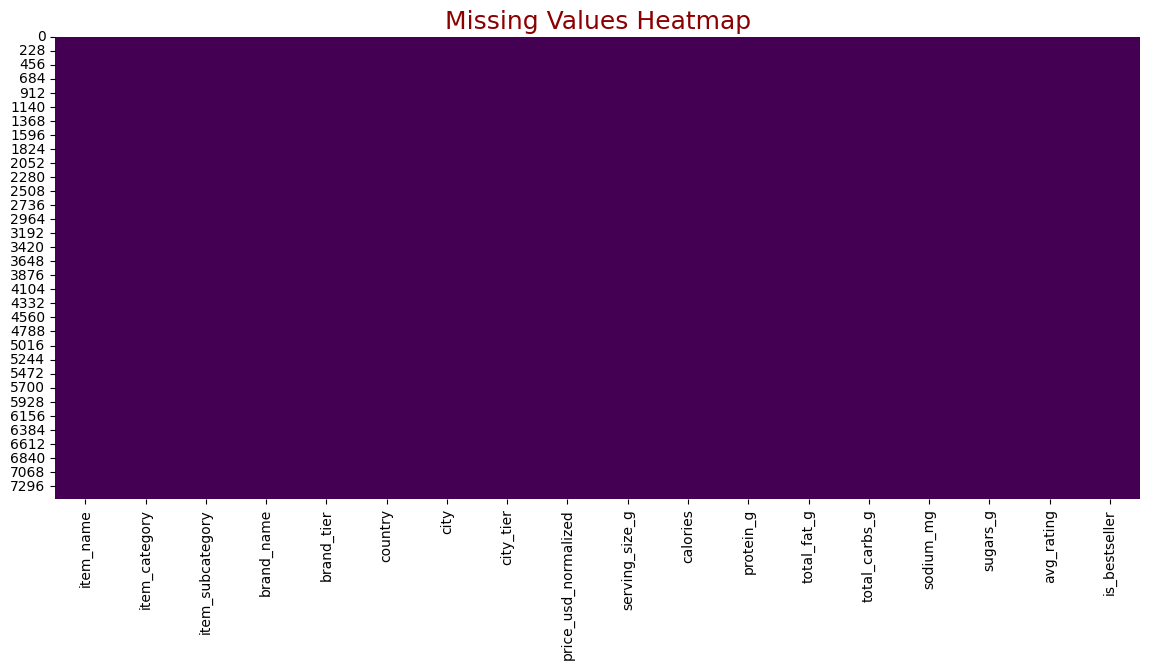

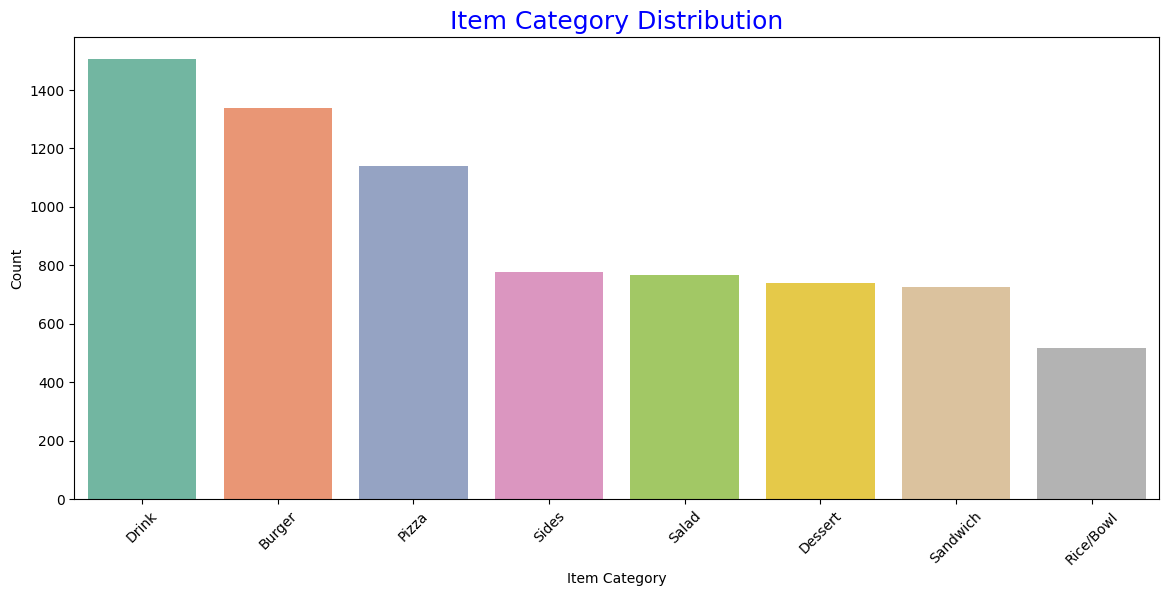

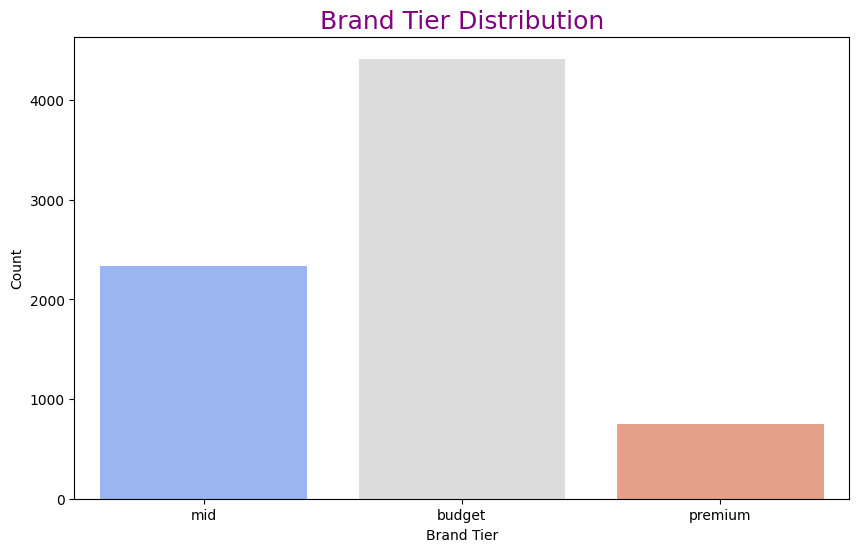

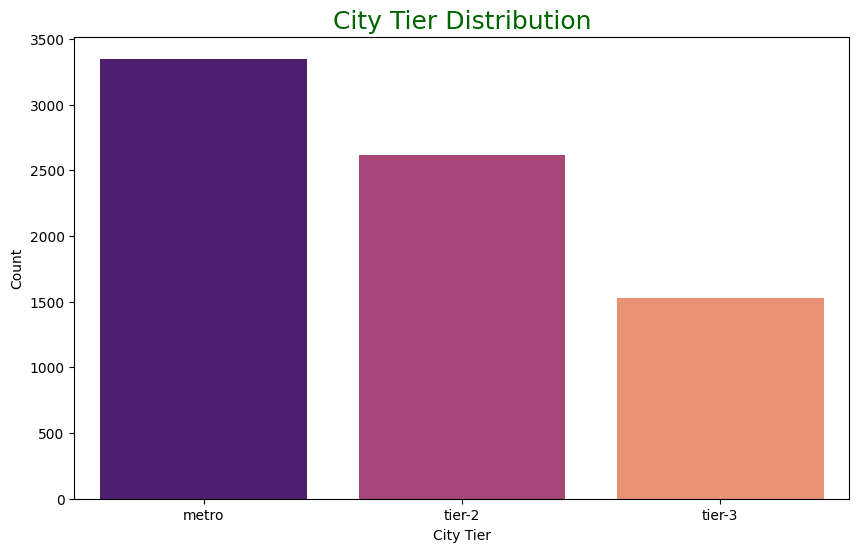

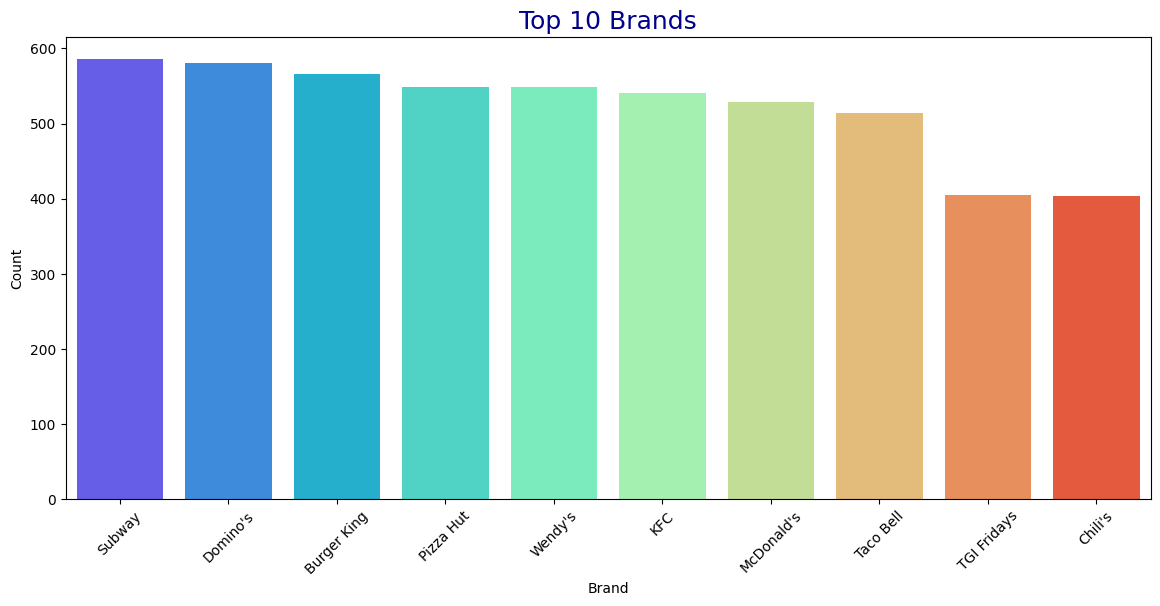

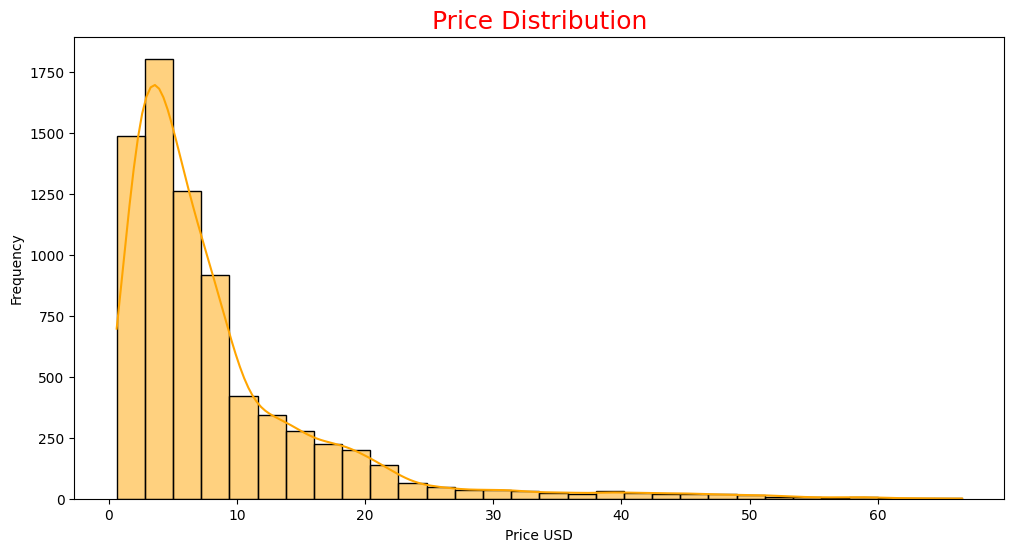

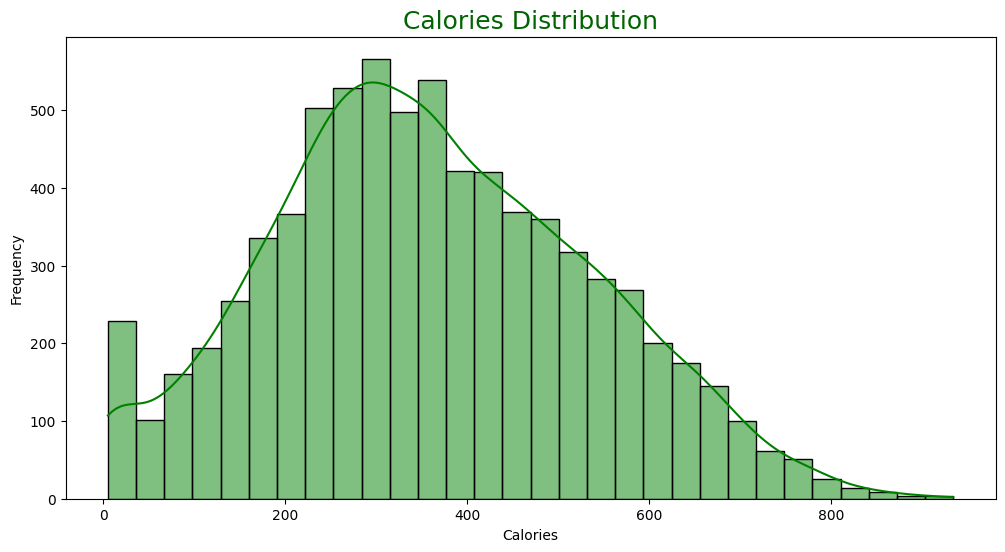

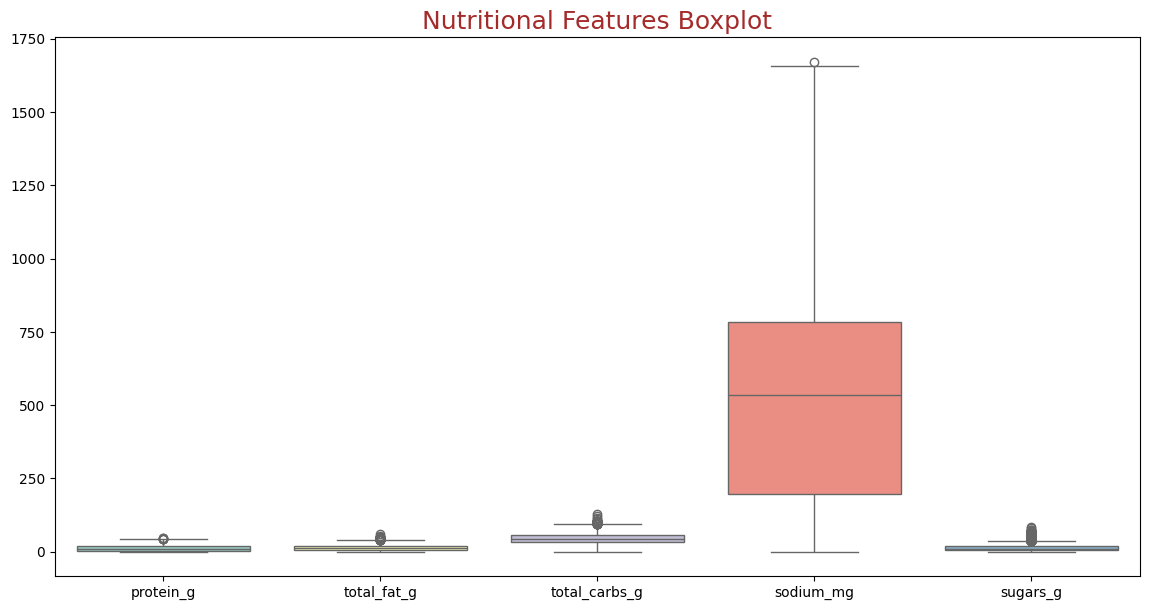

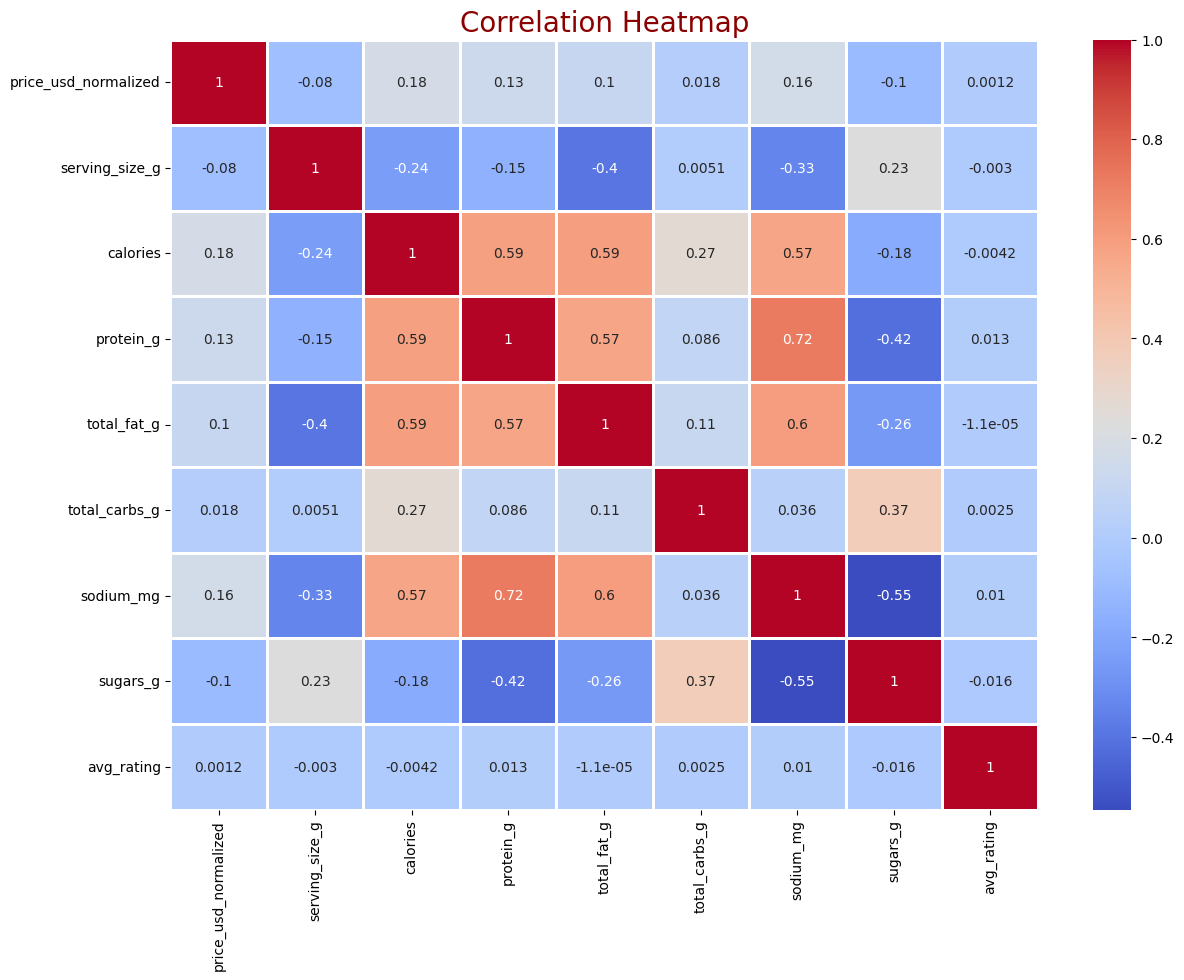

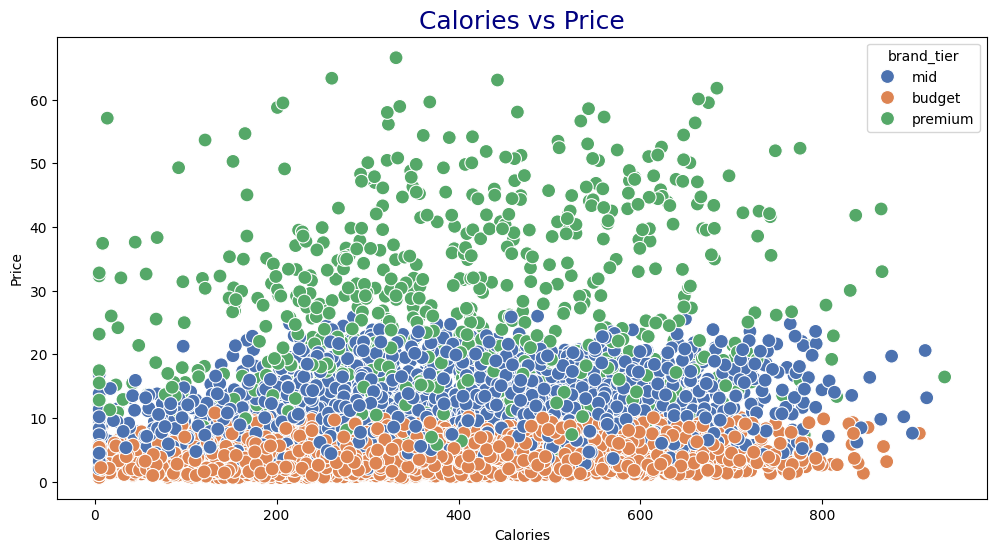

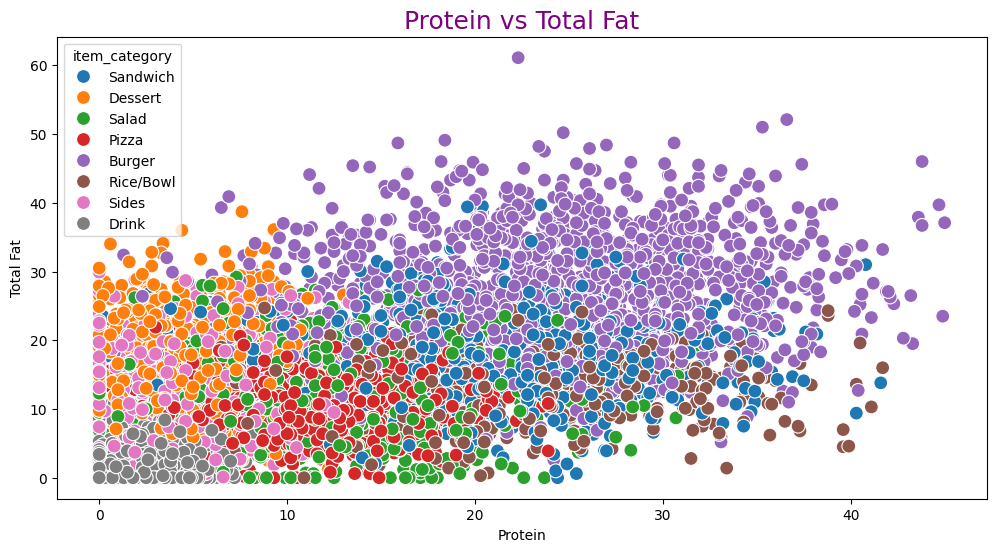

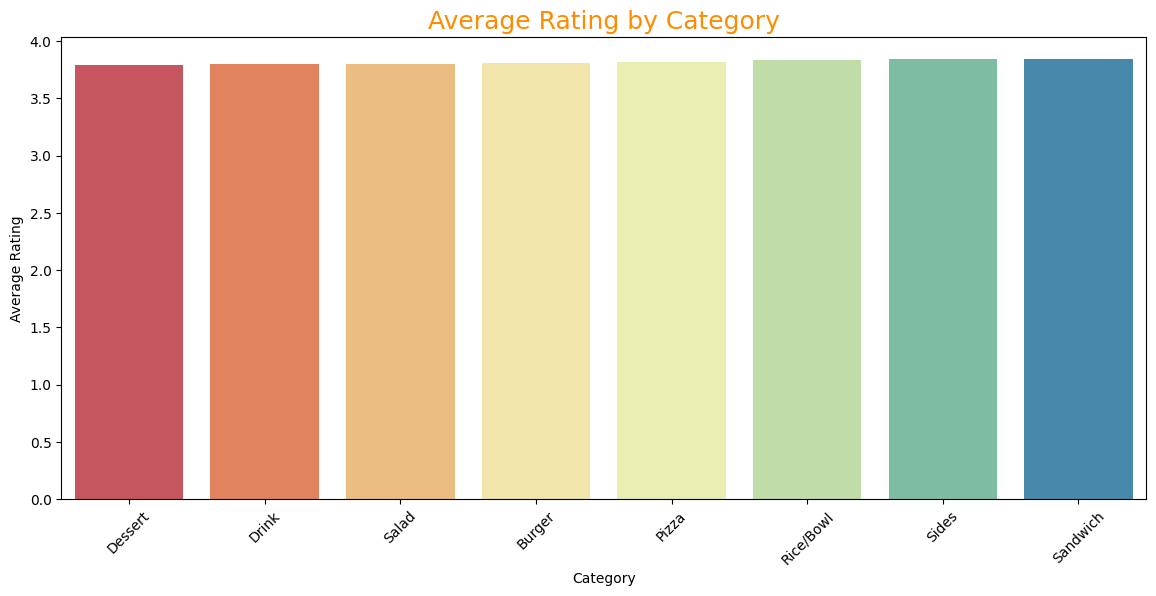

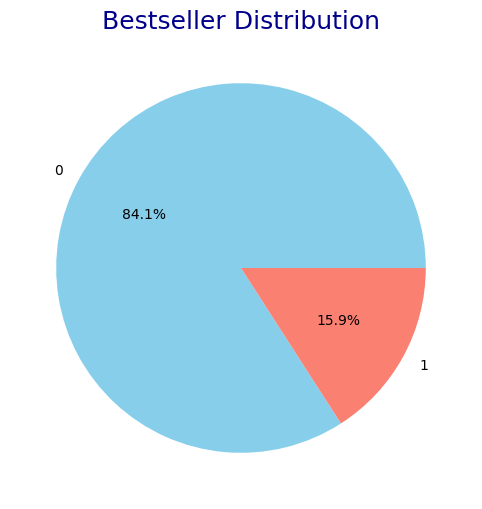

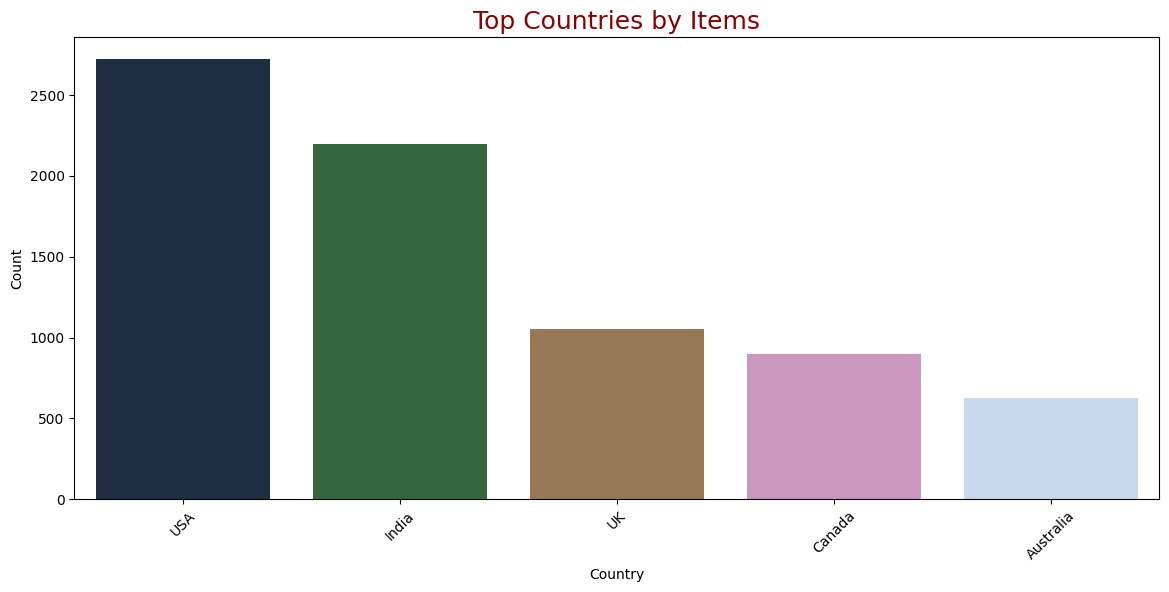

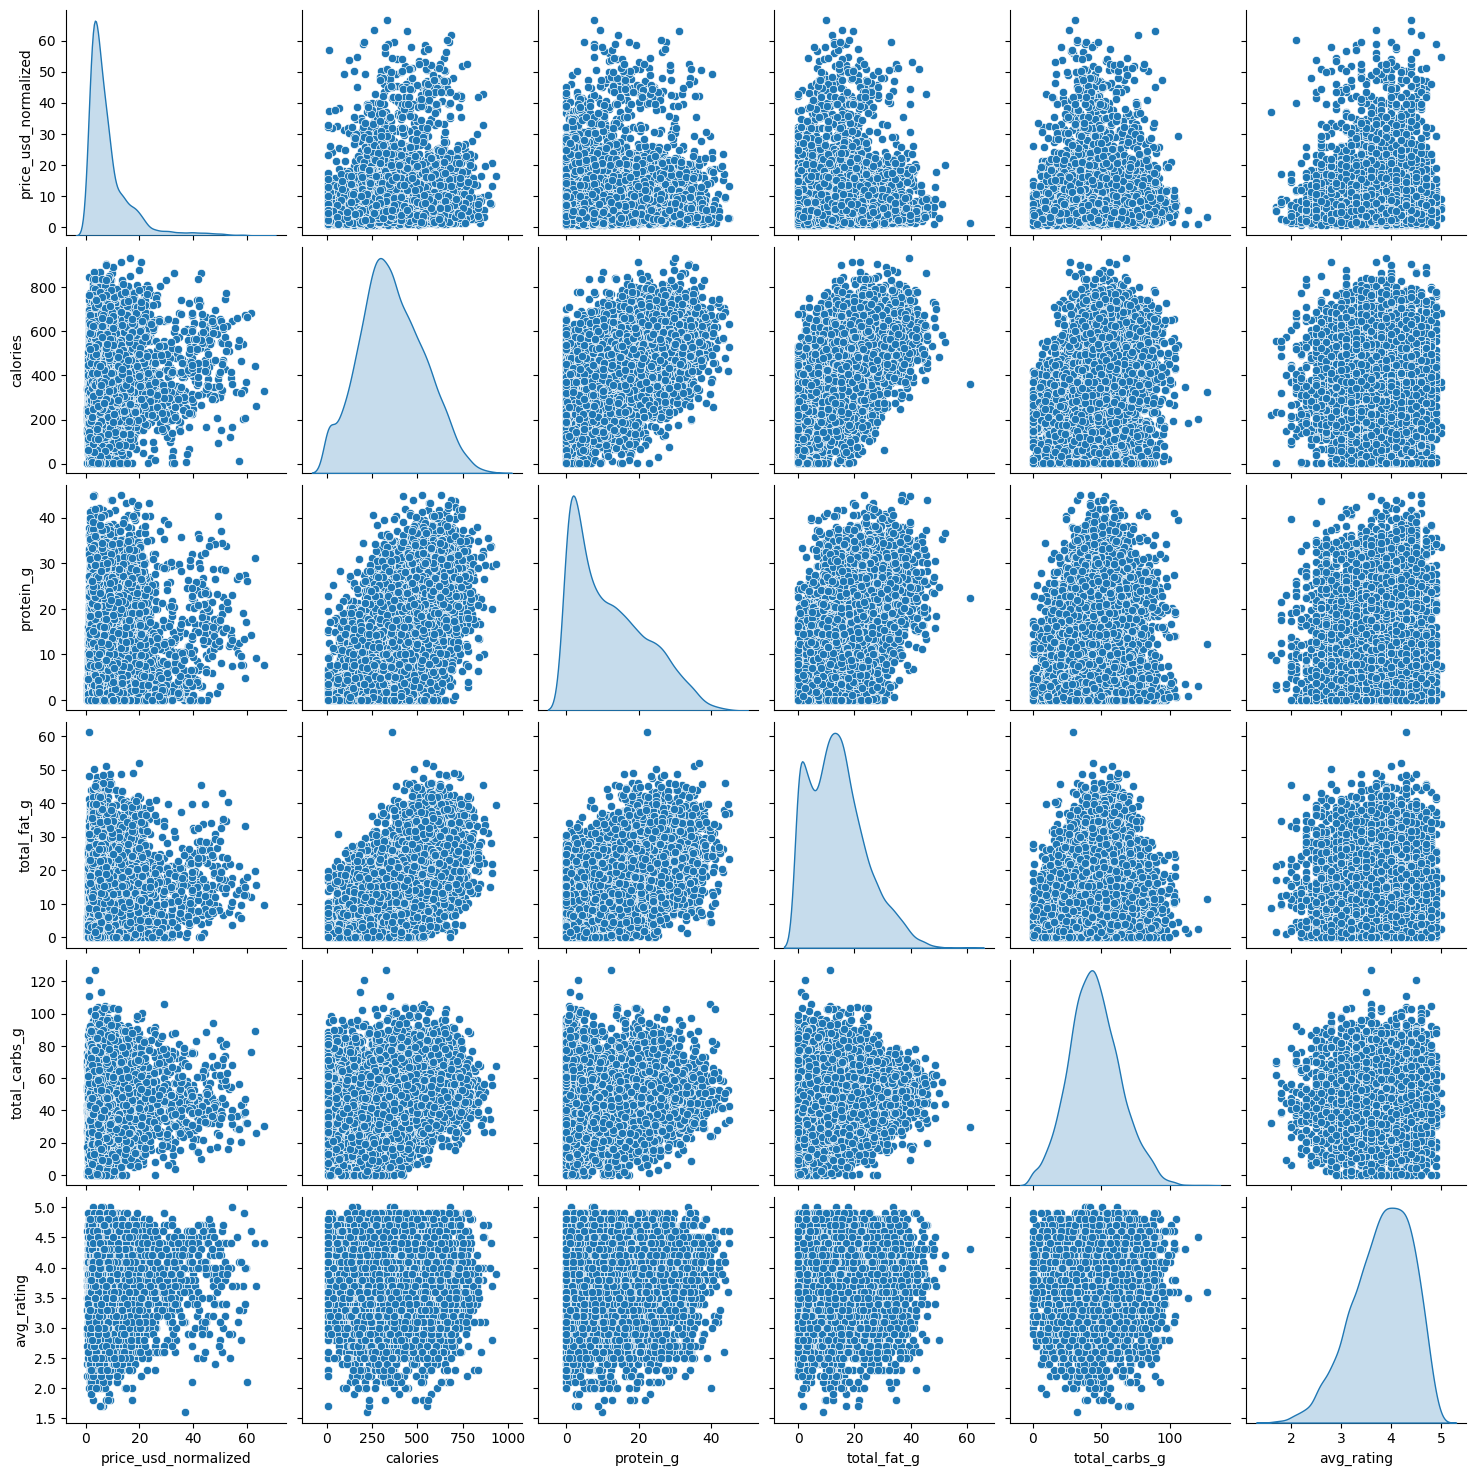

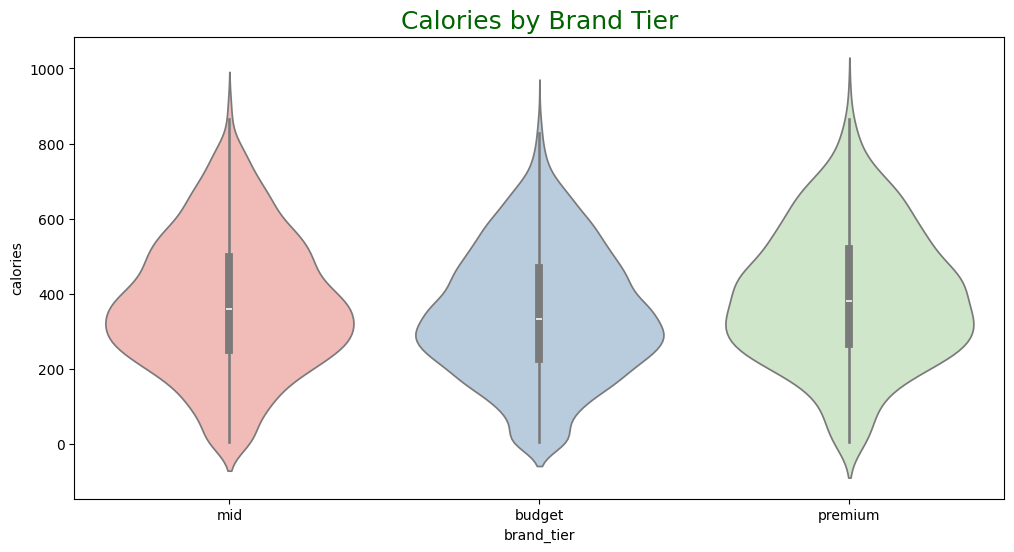

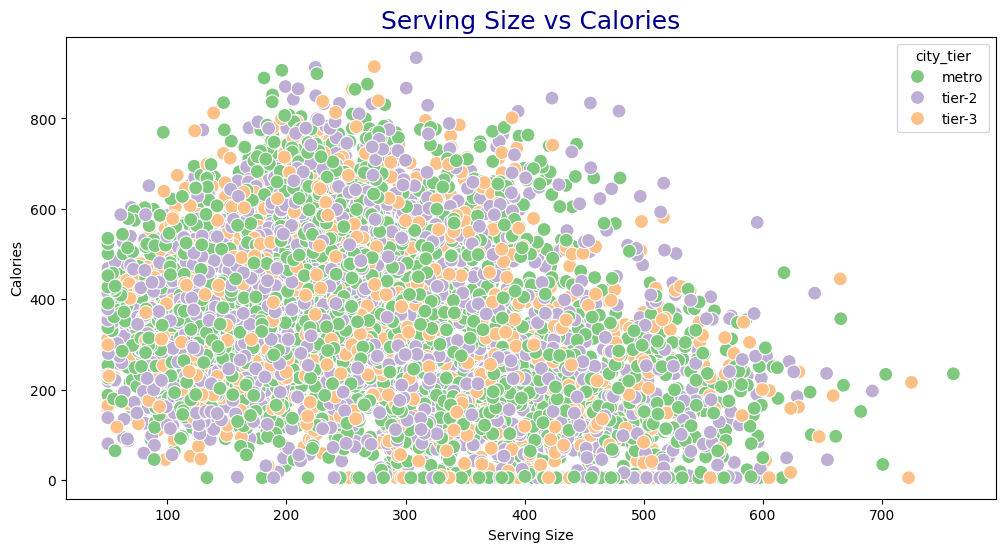

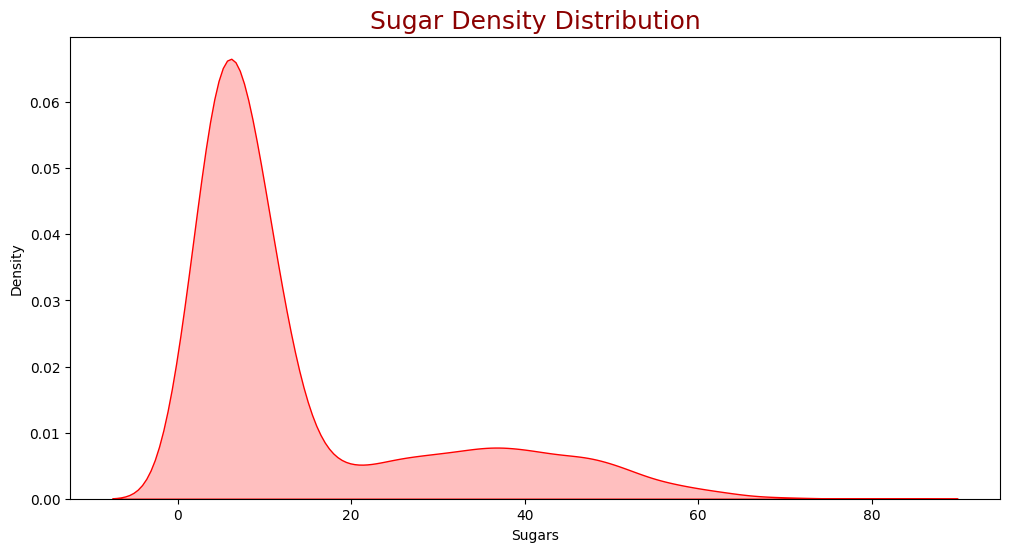

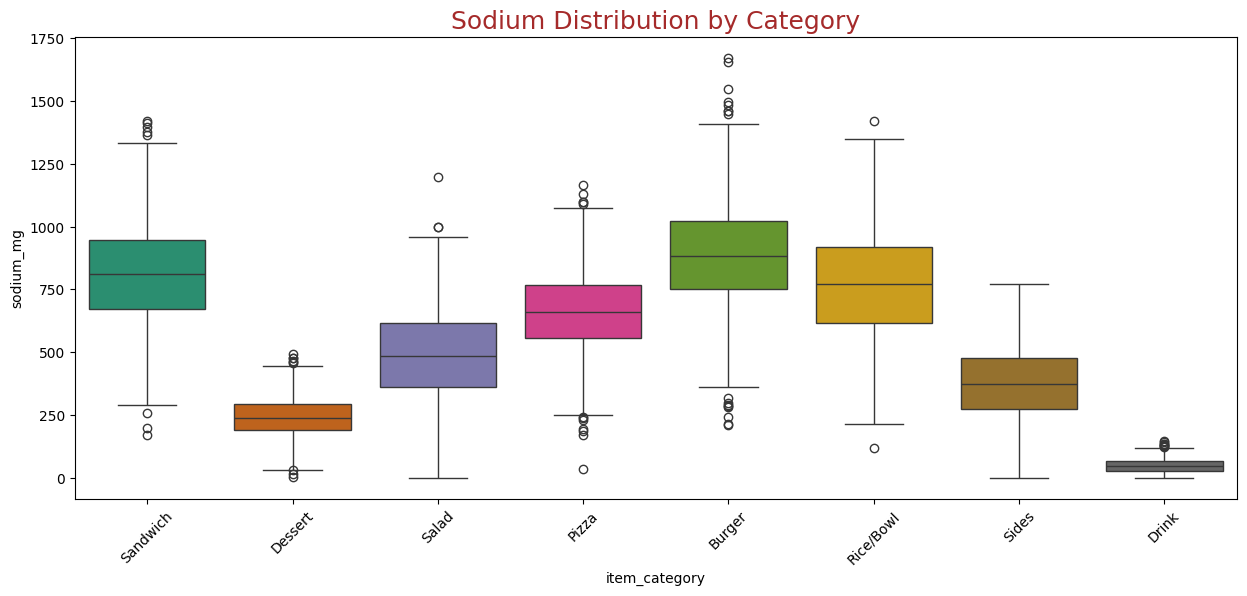

Visualization Completed Successfully


In [13]:
# ==========================================
# 1. Missing Values Visualization
# ==========================================
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=18, color='darkred')
plt.show()

# ==========================================
# 2. Item Category Count
# ==========================================
plt.figure(figsize=(14,6))

category_counts = df['item_category'].value_counts()

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Item Category Distribution", fontsize=18, color='blue')
plt.xlabel("Item Category")
plt.ylabel("Count")
plt.show()

# ==========================================
# 3. Brand Tier Distribution
# ==========================================
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='brand_tier',
    palette='coolwarm'
)

plt.title("Brand Tier Distribution", fontsize=18, color='purple')
plt.xlabel("Brand Tier")
plt.ylabel("Count")
plt.show()

# ==========================================
# 4. City Tier Distribution
# ==========================================
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='city_tier',
    palette='magma'
)

plt.title("City Tier Distribution", fontsize=18, color='darkgreen')
plt.xlabel("City Tier")
plt.ylabel("Count")
plt.show()

# ==========================================
# 5. Top 10 Brands
# ==========================================
plt.figure(figsize=(14,6))

top_brands = df['brand_name'].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values,
    palette='rainbow'
)

plt.xticks(rotation=45)
plt.title("Top 10 Brands", fontsize=18, color='darkblue')
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

# ==========================================
# 6. Price Distribution
# ==========================================
plt.figure(figsize=(12,6))

sns.histplot(
    df['price_usd_normalized'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Price Distribution", fontsize=18, color='red')
plt.xlabel("Price USD")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 7. Calories Distribution
# ==========================================
plt.figure(figsize=(12,6))

sns.histplot(
    df['calories'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Calories Distribution", fontsize=18, color='darkgreen')
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 8. Nutritional Features Boxplot
# ==========================================
nutrition_cols = [
    'protein_g',
    'total_fat_g',
    'total_carbs_g',
    'sodium_mg',
    'sugars_g'
]

plt.figure(figsize=(14,7))

sns.boxplot(
    data=df[nutrition_cols],
    palette='Set3'
)

plt.title("Nutritional Features Boxplot", fontsize=18, color='brown')
plt.show()

# ==========================================
# 9. Correlation Heatmap
# ==========================================
numeric_cols = [
    'price_usd_normalized',
    'serving_size_g',
    'calories',
    'protein_g',
    'total_fat_g',
    'total_carbs_g',
    'sodium_mg',
    'sugars_g',
    'avg_rating'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=20, color='darkred')
plt.show()

# ==========================================
# 10. Scatter Plot - Calories vs Price
# ==========================================
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='calories',
    y='price_usd_normalized',
    hue='brand_tier',
    palette='deep',
    s=100
)

plt.title("Calories vs Price", fontsize=18, color='navy')
plt.xlabel("Calories")
plt.ylabel("Price")
plt.show()

# ==========================================
# 11. Protein vs Fat
# ==========================================
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='protein_g',
    y='total_fat_g',
    hue='item_category',
    palette='tab10',
    s=100
)

plt.title("Protein vs Total Fat", fontsize=18, color='purple')
plt.xlabel("Protein")
plt.ylabel("Total Fat")
plt.show()

# ==========================================
# 12. Average Rating by Category
# ==========================================
plt.figure(figsize=(14,6))

avg_rating_category = df.groupby('item_category')['avg_rating'].mean().sort_values()

sns.barplot(
    x=avg_rating_category.index,
    y=avg_rating_category.values,
    palette='Spectral'
)

plt.xticks(rotation=45)
plt.title("Average Rating by Category", fontsize=18, color='darkorange')
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

# ==========================================
# 13. Bestseller Distribution
# ==========================================
plt.figure(figsize=(8,6))

colors = ['skyblue', 'salmon']

df['is_bestseller'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Bestseller Distribution", fontsize=18, color='darkblue')
plt.ylabel("")
plt.show()

# ==========================================
# 14. Country-wise Item Distribution
# ==========================================
plt.figure(figsize=(14,6))

top_country = df['country'].value_counts().head(10)

sns.barplot(
    x=top_country.index,
    y=top_country.values,
    palette='cubehelix'
)

plt.xticks(rotation=45)
plt.title("Top Countries by Items", fontsize=18, color='darkred')
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# ==========================================
# 15. Pairplot for Numerical Features
# ==========================================
pairplot_cols = [
    'price_usd_normalized',
    'calories',
    'protein_g',
    'total_fat_g',
    'total_carbs_g',
    'avg_rating'
]

sns.pairplot(
    df[pairplot_cols],
    diag_kind='kde'
)

plt.show()

# ==========================================
# 16. Violin Plot - Calories by Brand Tier
# ==========================================
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='brand_tier',
    y='calories',
    palette='Pastel1'
)

plt.title("Calories by Brand Tier", fontsize=18, color='darkgreen')
plt.show()

# ==========================================
# 17. Serving Size vs Calories
# ==========================================
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='serving_size_g',
    y='calories',
    hue='city_tier',
    palette='Accent',
    s=100
)

plt.title("Serving Size vs Calories", fontsize=18, color='darkblue')
plt.xlabel("Serving Size")
plt.ylabel("Calories")
plt.show()

# ==========================================
# 18. KDE Plot of Sugars
# ==========================================
plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x='sugars_g',
    fill=True,
    color='red'
)

plt.title("Sugar Density Distribution", fontsize=18, color='darkred')
plt.xlabel("Sugars")
plt.show()

# ==========================================
# 19. Sodium Distribution by Category
# ==========================================
plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x='item_category',
    y='sodium_mg',
    palette='Dark2'
)

plt.xticks(rotation=45)
plt.title("Sodium Distribution by Category", fontsize=18, color='brown')
plt.show()

# ==========================================
# 20. Final Summary
# ==========================================
print("Visualization Completed Successfully")

## Feature engineering



Train Shape : (6000, 17)
Test Shape  : (1500, 17)


MODEL : Logistic Regression

Accuracy  : 0.8407
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.4928

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1261
           1       0.00      0.00      0.00       239

    accuracy                           0.84      1500
   macro avg       0.42      0.50      0.46      1500
weighted avg       0.71      0.84      0.77      1500



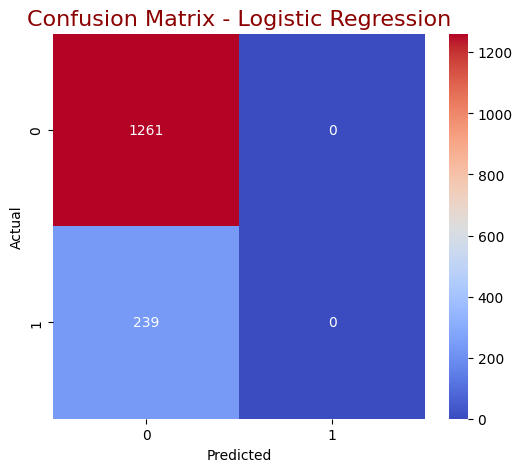

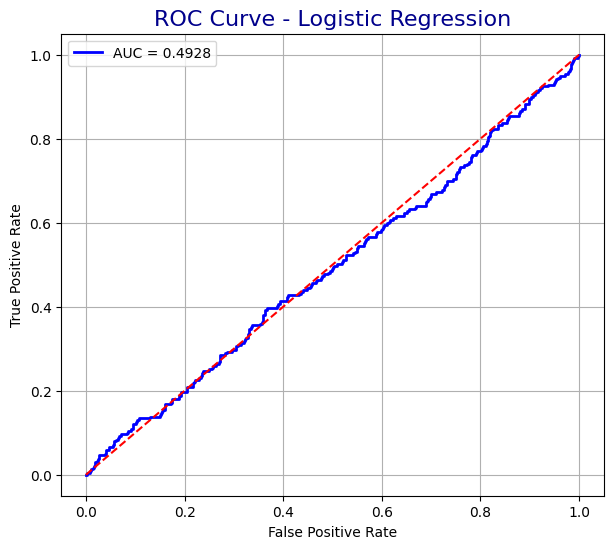



MODEL : Decision Tree

Accuracy  : 0.8193
Precision : 0.1000
Recall    : 0.0167
F1 Score  : 0.0287
ROC AUC   : 0.5128

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1261
           1       0.10      0.02      0.03       239

    accuracy                           0.82      1500
   macro avg       0.47      0.49      0.46      1500
weighted avg       0.72      0.82      0.76      1500



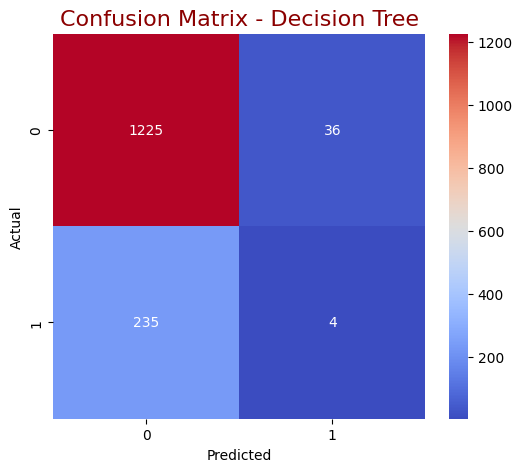

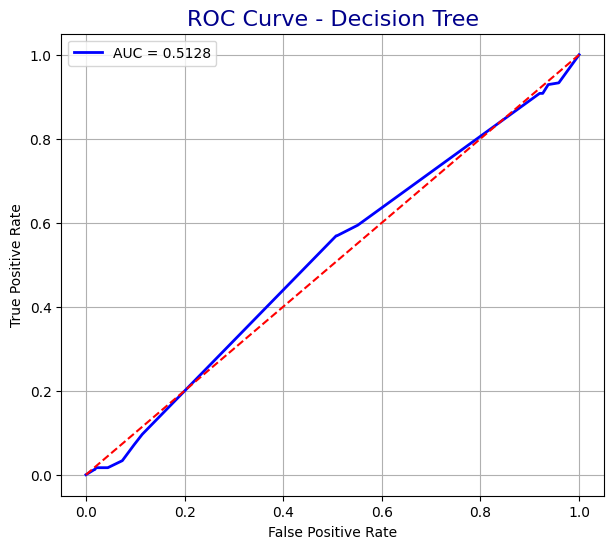



MODEL : Random Forest

Accuracy  : 0.8407
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.5263

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1261
           1       0.00      0.00      0.00       239

    accuracy                           0.84      1500
   macro avg       0.42      0.50      0.46      1500
weighted avg       0.71      0.84      0.77      1500



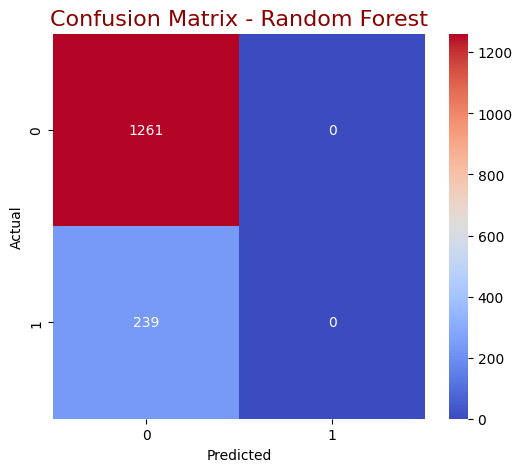

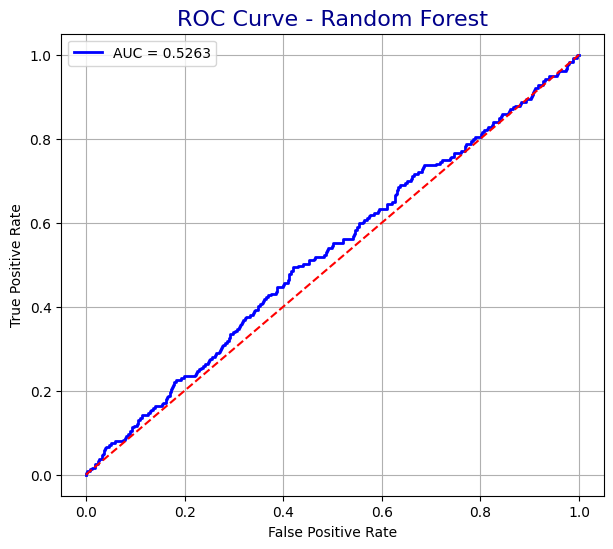



MODEL : Gradient Boosting

Accuracy  : 0.8380
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.5214

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1261
           1       0.00      0.00      0.00       239

    accuracy                           0.84      1500
   macro avg       0.42      0.50      0.46      1500
weighted avg       0.71      0.84      0.77      1500



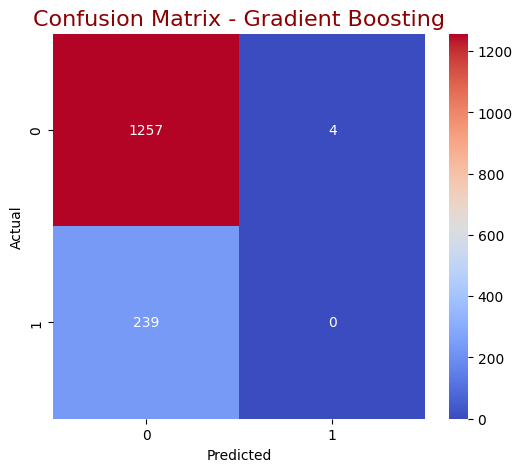

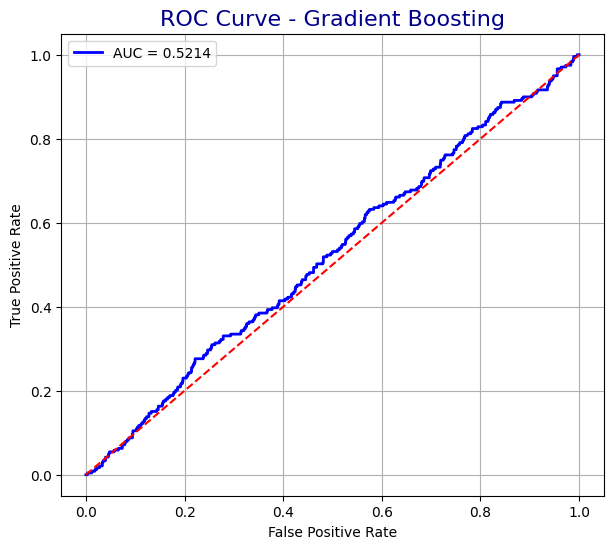



MODEL : KNN

Accuracy  : 0.8147
Precision : 0.1176
Recall    : 0.0251
F1 Score  : 0.0414
ROC AUC   : 0.5326

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1261
           1       0.12      0.03      0.04       239

    accuracy                           0.81      1500
   macro avg       0.48      0.49      0.47      1500
weighted avg       0.72      0.81      0.76      1500



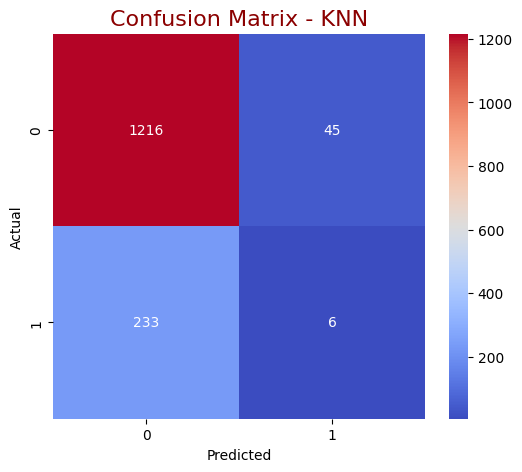

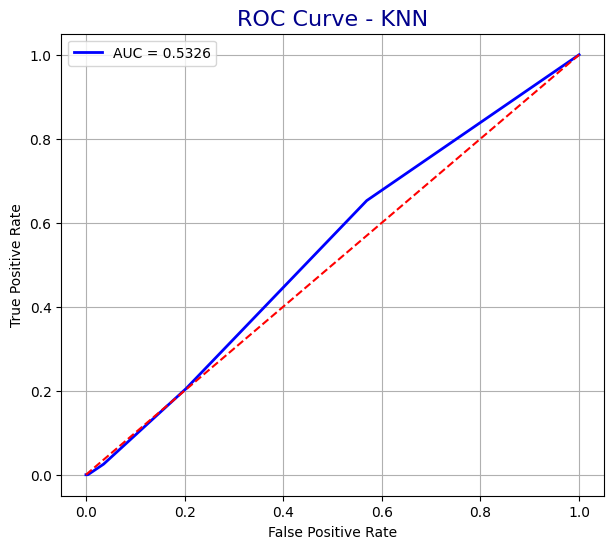



MODEL : Naive Bayes

Accuracy  : 0.4920
Precision : 0.1499
Recall    : 0.4686
F1 Score  : 0.2272
ROC AUC   : 0.4740

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.50      0.62      1261
           1       0.15      0.47      0.23       239

    accuracy                           0.49      1500
   macro avg       0.49      0.48      0.42      1500
weighted avg       0.72      0.49      0.56      1500



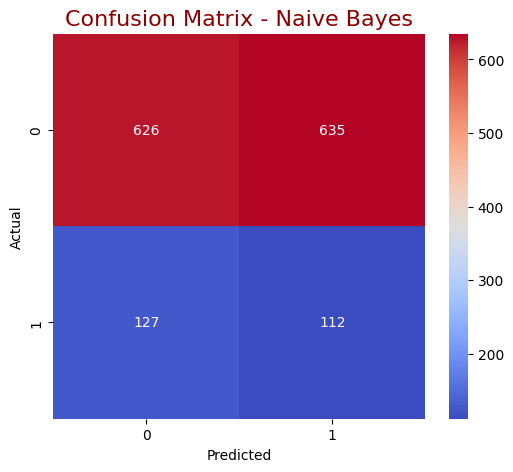

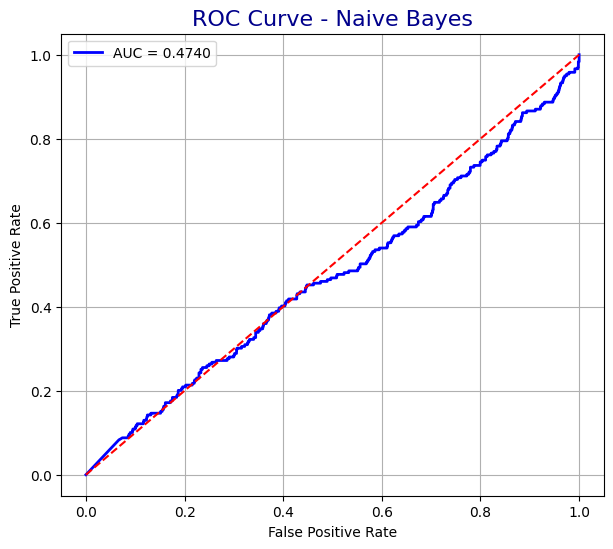



MODEL : SVM

Accuracy  : 0.8407
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.4992

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1261
           1       0.00      0.00      0.00       239

    accuracy                           0.84      1500
   macro avg       0.42      0.50      0.46      1500
weighted avg       0.71      0.84      0.77      1500



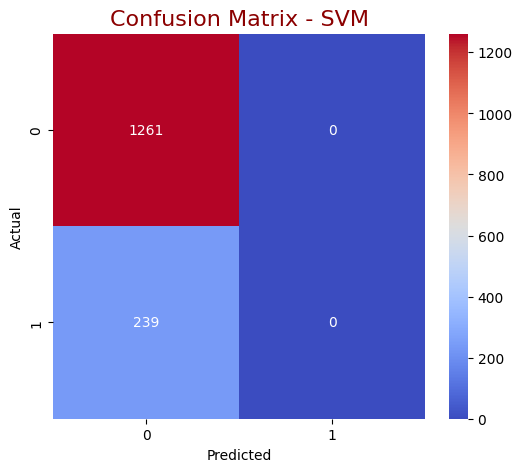

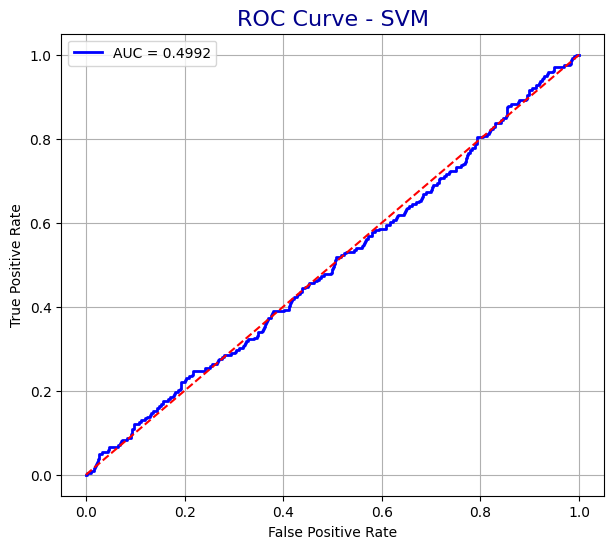



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.840667   0.000000  0.000000  0.000000  0.492835
2        Random Forest  0.840667   0.000000  0.000000  0.000000  0.526331
6                  SVM  0.840667   0.000000  0.000000  0.000000  0.499175
3    Gradient Boosting  0.838000   0.000000  0.000000  0.000000  0.521355
1        Decision Tree  0.819333   0.100000  0.016736  0.028674  0.512811
4                  KNN  0.814667   0.117647  0.025105  0.041379  0.532618
5          Naive Bayes  0.492000   0.149933  0.468619  0.227181  0.474046


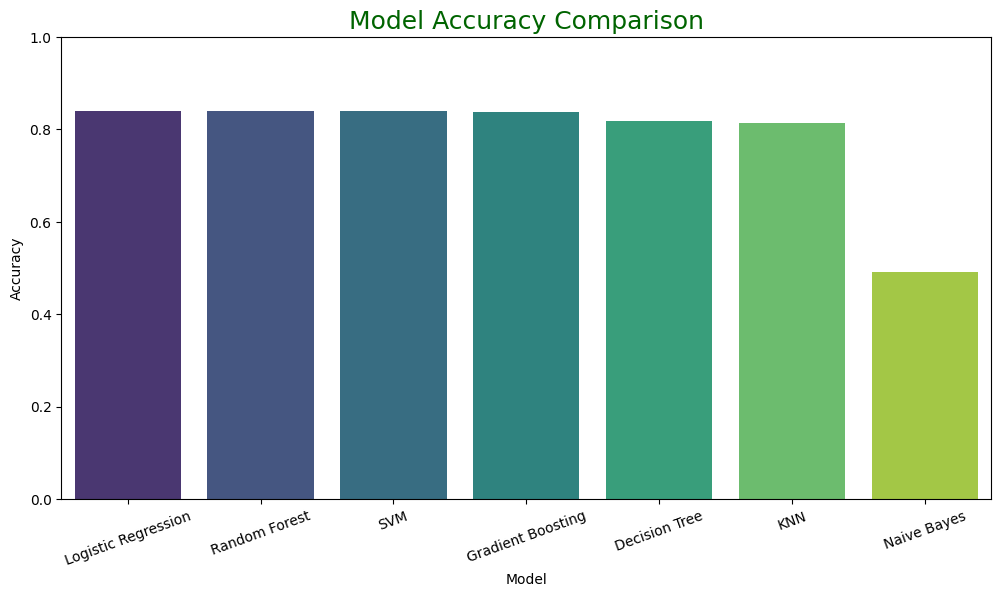

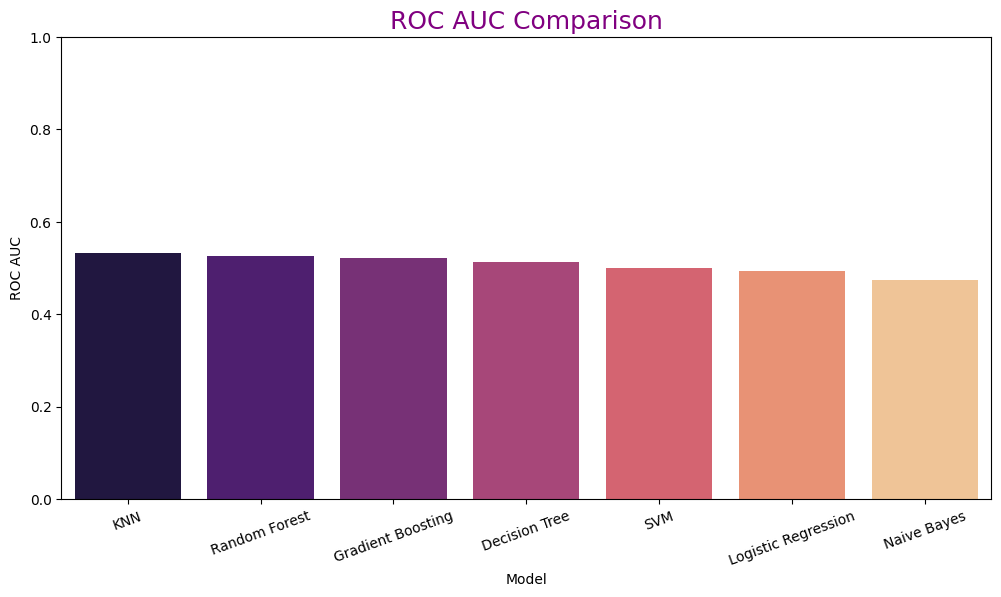



BEST MODEL
Model        Logistic Regression
Accuracy                0.840667
Precision                    0.0
Recall                       0.0
F1 Score                     0.0
ROC AUC                 0.492835
Name: 0, dtype: object

Pipeline Completed Successfully


In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    RocCurveDisplay
)


target = 'is_bestseller'

# =========================================================
# FEATURES & TARGET
# =========================================================
X = df.drop(columns=[target])
y = df[target]

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================
categorical_cols = [
    'item_name',
    'item_category',
    'item_subcategory',
    'brand_name',
    'brand_tier',
    'country',
    'city',
    'city_tier'
]

numerical_cols = [
    'price_usd_normalized',
    'serving_size_g',
    'calories',
    'protein_g',
    'total_fat_g',
    'total_carbs_g',
    'sodium_mg',
    'sugars_g',
    'avg_rating'
]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Split BEFORE preprocessing to avoid data leakage
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# =========================================================
# PREPROCESSING
# =========================================================
# OneHotEncoding for categorical columns
# StandardScaler for numerical columns
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ]
)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(
        probability=True,
        kernel='rbf',
        random_state=42
    )
}

# =========================================================
# STORE RESULTS
# =========================================================

results = []

# =========================================================
# TRAIN & EVALUATE MODELS
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL : {model_name}")
    print("="*70)

    # =====================================================
    # Special Handling for GaussianNB
    # =====================================================

    if model_name == "Naive Bayes":

        # Fit preprocessing
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # Convert sparse matrix to dense
        X_train_processed = X_train_processed.toarray()
        X_test_processed = X_test_processed.toarray()

        # Train model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probability predictions
        y_prob = model.predict_proba(X_test_processed)[:,1]

    else:

        # Create Pipeline
        pipeline = Pipeline(steps=[

            ('preprocessor', preprocessor),

            ('classifier', model)

        ])

        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)

        # Probability prediction
        y_prob = pipeline.predict_proba(X_test)[:,1]

    # =====================================================
    # METRICS
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = auc(
        *roc_curve(y_test, y_prob)[:2]
    )

    # Save Results
    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc

    })

    # =====================================================
    # PRINT METRICS
    # =====================================================

    print(f"\nAccuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(f'Confusion Matrix - {model_name}',
              fontsize=16,
              color='darkred')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        color='blue',
        linewidth=2,
        label=f'AUC = {roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--',
        color='red'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f'ROC Curve - {model_name}',
              fontsize=16,
              color='darkblue')

    plt.legend()
    plt.grid(True)

    plt.show()

# =========================================================
# RESULTS COMPARISON TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(
    by='Accuracy',
    ascending=False
))

# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df.sort_values(
        by='Accuracy',
        ascending=False
    ),
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title(
    'Model Accuracy Comparison',
    fontsize=18,
    color='darkgreen'
)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# VISUALIZE ROC AUC SCORES
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df.sort_values(
        by='ROC AUC',
        ascending=False
    ),
    x='Model',
    y='ROC AUC',
    palette='magma'
)

plt.title(
    'ROC AUC Comparison',
    fontsize=18,
    color='purple'
)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best_model)

print("\nPipeline Completed Successfully")

## Thank you...pls upvote!!!!!!!!!!!!!!